Weather data extracted successfully!

First 5 Rows:
           DateTime  Temperature  Humidity
0  2026-06-07T00:00         28.6        51
1  2026-06-07T01:00         29.2        49
2  2026-06-07T02:00         30.7        45
3  2026-06-07T03:00         32.7        39
4  2026-06-07T04:00         34.8        33

Missing Values Before Cleaning:
DateTime       0
Temperature    0
Humidity       0
dtype: int64

Missing Values After Cleaning:
DateTime       0
Temperature    0
Humidity       0
dtype: int64

Dataset Shape:
(72, 3)

Summary Statistics:
                  DateTime  Temperature   Humidity
count                   72    72.000000  72.000000
mean   2026-06-08 11:30:00    36.716667  29.277778
min    2026-06-07 00:00:00    28.600000  15.000000
25%    2026-06-07 17:45:00    33.600000  21.000000
50%    2026-06-08 11:30:00    37.100000  28.000000
75%    2026-06-09 05:15:00    39.950000  36.000000
max    2026-06-09 23:00:00    42.900000  51.000000
std                    NaN     3.862860   9.

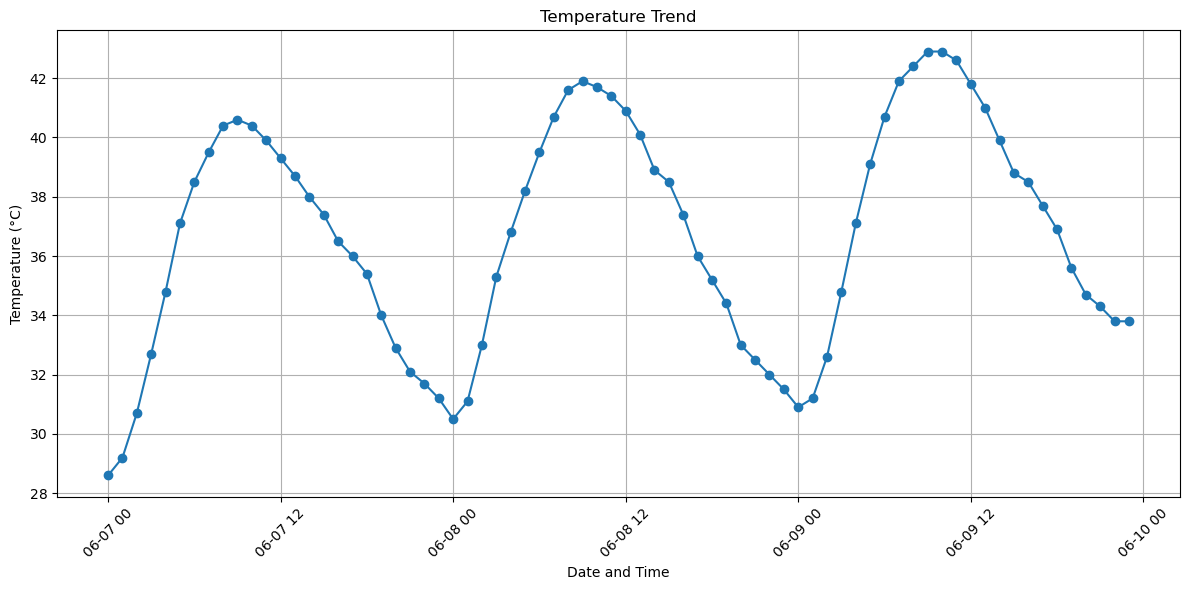

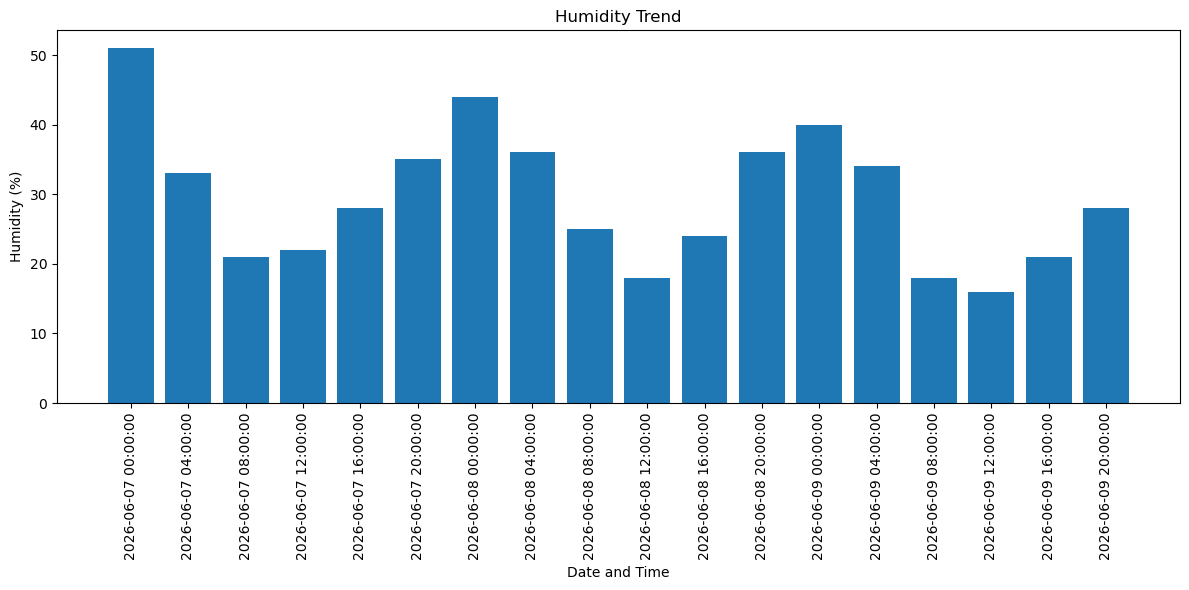


Real-World Benefits of Automation


1. Automatically collects real-time weather data.
2. Reduces manual data entry and human errors.
3. Helps farmers plan irrigation and harvesting.
4. Assists logistics companies in route optimization.
5. Supports airlines with weather-based planning.
6. Enables governments to issue weather alerts.
7. Helps businesses make data-driven decisions.
8. Saves time through automated monitoring and reporting.
    


In [2]:
# ==========================================
# Week 6 Assignment
# Real-Time Weather Data Extraction Project
# ==========================================

import requests
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# Step 1: Extract Weather Data from API
# ------------------------------------------

latitude = 28.6139
longitude = 77.2090

url = (
    f"https://api.open-meteo.com/v1/forecast?"
    f"latitude={latitude}&longitude={longitude}"
    f"&hourly=temperature_2m,relative_humidity_2m"
    f"&forecast_days=3"
)

response = requests.get(url)

if response.status_code == 200:

    data = response.json()

    print("Weather data extracted successfully!\n")

    # ------------------------------------------
    # Step 2: Convert JSON to DataFrame
    # ------------------------------------------

    df = pd.DataFrame({
        "DateTime": data["hourly"]["time"],
        "Temperature": data["hourly"]["temperature_2m"],
        "Humidity": data["hourly"]["relative_humidity_2m"]
    })

    print("First 5 Rows:")
    print(df.head())

    # ------------------------------------------
    # Step 3: Data Cleaning
    # ------------------------------------------

    print("\nMissing Values Before Cleaning:")
    print(df.isnull().sum())

    # Remove duplicates
    df = df.drop_duplicates()

    # Fill missing values
    df = df.ffill()

    # Convert DateTime column
    df["DateTime"] = pd.to_datetime(df["DateTime"])

    print("\nMissing Values After Cleaning:")
    print(df.isnull().sum())

    print("\nDataset Shape:")
    print(df.shape)

    # ------------------------------------------
    # Step 4: Summary Statistics
    # ------------------------------------------

    print("\nSummary Statistics:")
    print(df.describe())

    # ------------------------------------------
    # Step 5: Temperature Trend (Line Chart)
    # ------------------------------------------

    plt.figure(figsize=(12, 6))

    plt.plot(
        df["DateTime"],
        df["Temperature"],
        marker="o"
    )

    plt.title("Temperature Trend")
    plt.xlabel("Date and Time")
    plt.ylabel("Temperature (°C)")
    plt.xticks(rotation=45)
    plt.grid(True)

    plt.tight_layout()

    plt.savefig("Temperature_Trend.png")
    plt.show()

    # ------------------------------------------
    # Step 6: Humidity Trend (Bar Chart)
    # ------------------------------------------

    plt.figure(figsize=(12, 6))

    sample_df = df.iloc[::4]

    plt.bar(
        sample_df["DateTime"].astype(str),
        sample_df["Humidity"]
    )

    plt.title("Humidity Trend")
    plt.xlabel("Date and Time")
    plt.ylabel("Humidity (%)")

    plt.xticks(rotation=90)

    plt.tight_layout()

    plt.savefig("Humidity_Trend.png")
    plt.show()

    # ------------------------------------------
    # Step 7: Real-World Benefits
    # ------------------------------------------

    print("\nReal-World Benefits of Automation\n")

    print("""
1. Automatically collects real-time weather data.
2. Reduces manual data entry and human errors.
3. Helps farmers plan irrigation and harvesting.
4. Assists logistics companies in route optimization.
5. Supports airlines with weather-based planning.
6. Enables governments to issue weather alerts.
7. Helps businesses make data-driven decisions.
8. Saves time through automated monitoring and reporting.
    """)

else:

    print("API Request Failed")
    print("Status Code:", response.status_code)
    print(response.text)

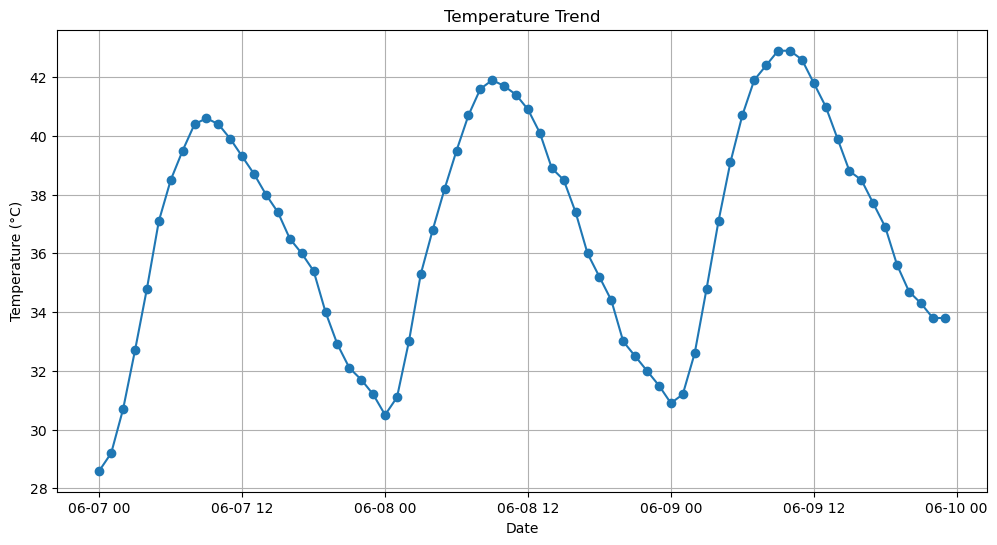

In [3]:
plt.figure(figsize=(12,6))
plt.plot(df["DateTime"], df["Temperature"], marker='o')
plt.title("Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

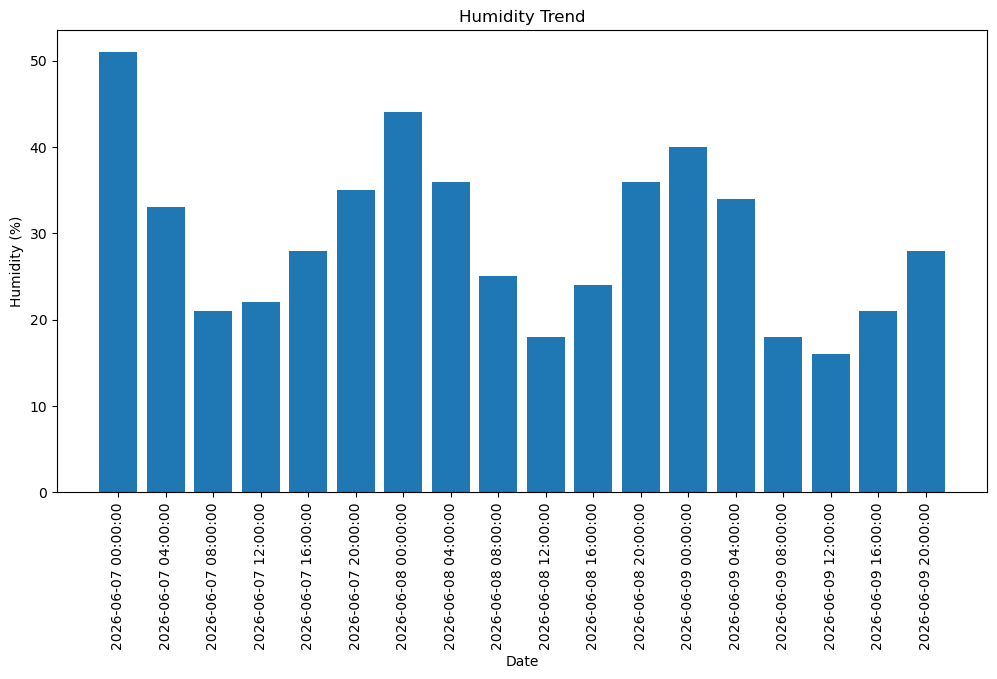

In [4]:
sample_df = df.iloc[::4]

plt.figure(figsize=(12,6))
plt.bar(sample_df["DateTime"].astype(str), sample_df["Humidity"])
plt.title("Humidity Trend")
plt.xlabel("Date")
plt.ylabel("Humidity (%)")
plt.xticks(rotation=90)
plt.show()

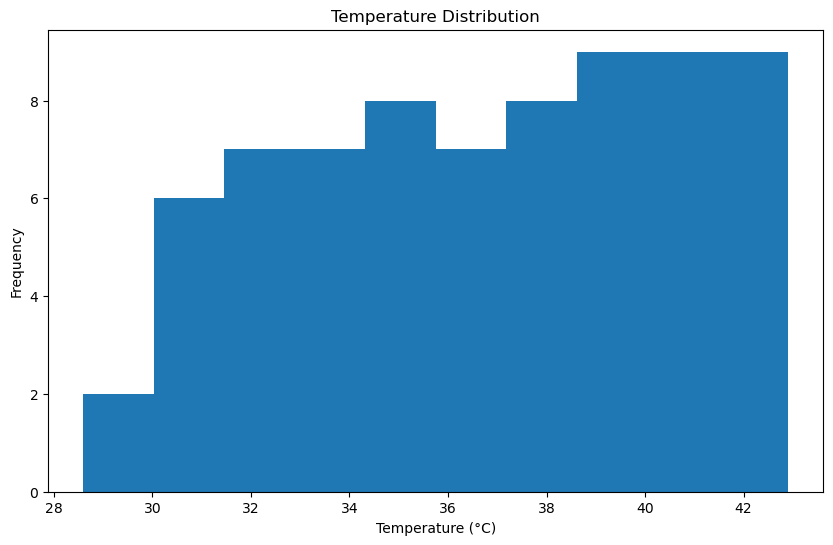

In [5]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Temperature"],
    bins=10
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

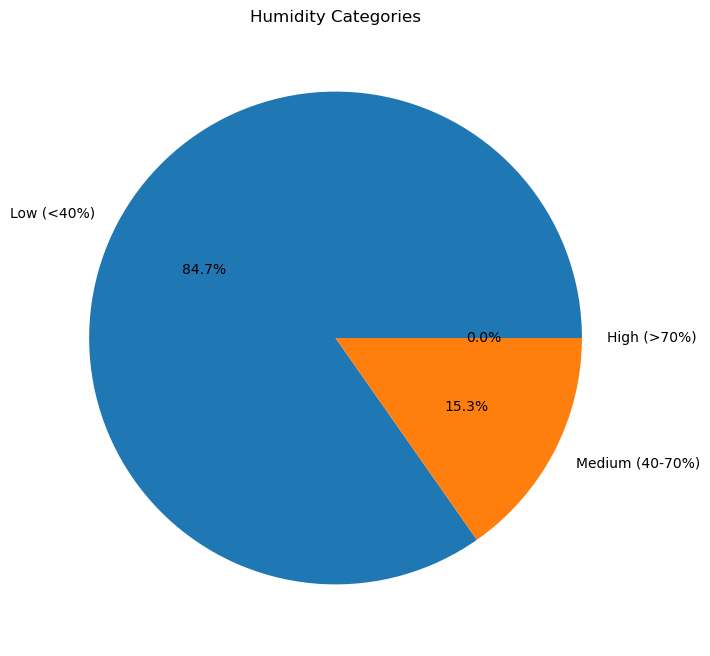

In [6]:
humidity_categories = {
    "Low (<40%)": len(df[df["Humidity"] < 40]),
    "Medium (40-70%)": len(df[(df["Humidity"] >= 40) & (df["Humidity"] <= 70)]),
    "High (>70%)": len(df[df["Humidity"] > 70])
}

plt.figure(figsize=(8,8))

plt.pie(
    humidity_categories.values(),
    labels=humidity_categories.keys(),
    autopct="%1.1f%%"
)

plt.title("Humidity Categories")

plt.show()

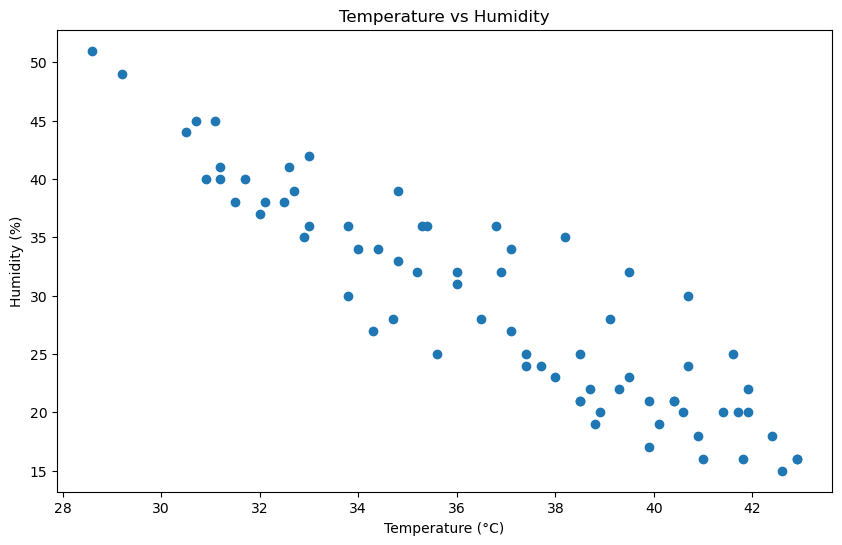

In [7]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Temperature"],
    df["Humidity"]
)

plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")

plt.show()

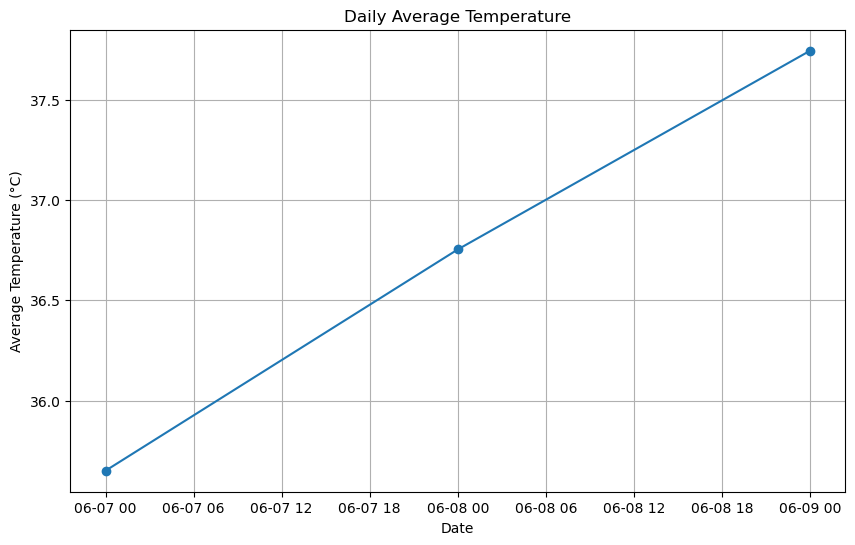

In [8]:
daily_temp = df.groupby(
    df["DateTime"].dt.date
)["Temperature"].mean()

plt.figure(figsize=(10,6))

plt.plot(
    daily_temp.index,
    daily_temp.values,
    marker="o"
)

plt.title("Daily Average Temperature")
plt.xlabel("Date")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)

plt.show()

In [18]:

print("Explain how such automation benefits real-world decision-making.")

print('\n')

# Used triple quotes to properly handle the multi-line string
print("""Automation of weather data extraction and analysis provides organizations with timely and accurate information for making informed decisions. Instead of manually collecting and processing weather data, Python scripts can automatically retrieve real-time data from APIs, clean the data, and generate visual reports.

Some key benefits include:

Faster Decision-Making – Real-time weather updates allow businesses and individuals to react quickly to changing conditions.
Improved Agricultural Planning – Farmers can use weather forecasts to schedule irrigation, planting, and harvesting activities, reducing crop losses.
Efficient Transportation and Logistics – Logistics companies can optimize delivery routes and schedules based on weather conditions, reducing delays and costs.
Disaster Management and Public Safety – Governments and emergency services can monitor severe weather events and issue timely warnings to protect lives and property.
Better Resource Allocation – Businesses can plan staffing, inventory, and operations according to expected weather patterns.
Reduced Human Error – Automated data collection and processing eliminate mistakes that can occur during manual data entry and analysis.
Cost and Time Savings – Automation reduces the effort required to gather and analyze data, allowing organizations to focus on strategic planning.
Data-Driven Insights – Visualizations such as line charts, bar charts, histograms, and scatter plots help identify trends and patterns, supporting more accurate and evidence-based decisions.
Conclusion

By automatically extracting weather data from an API, cleaning it, and visualizing trends, organizations can gain real-time insights that improve planning, efficiency, and decision-making. This demonstrates how data automation plays an important role in modern business operations, agriculture, transportation, public safety, and many other industries.""")

Explain how such automation benefits real-world decision-making.


Automation of weather data extraction and analysis provides organizations with timely and accurate information for making informed decisions. Instead of manually collecting and processing weather data, Python scripts can automatically retrieve real-time data from APIs, clean the data, and generate visual reports.

Some key benefits include:

Faster Decision-Making – Real-time weather updates allow businesses and individuals to react quickly to changing conditions.
Improved Agricultural Planning – Farmers can use weather forecasts to schedule irrigation, planting, and harvesting activities, reducing crop losses.
Efficient Transportation and Logistics – Logistics companies can optimize delivery routes and schedules based on weather conditions, reducing delays and costs.
Disaster Management and Public Safety – Governments and emergency services can monitor severe weather events and issue timely warnings to protect lives an